In [ ]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Load both datasets
url_1 = 'https://raw.githubusercontent.com/pablo9ja/NRF_work/main/Prostate%20Cancer%202.xlsx'
url_2 = 'https://raw.githubusercontent.com/pablo9ja/NRF_work/main/Prostate%20Data%2022.xlsx'

df = pd.read_excel(url_1)   # shape: (42, 29)
df2 = pd.read_excel(url_2)  # shape: (1013, 30)
df4 = pd.read_excel('C:\Users\lenovo\Documents\GitHub\NRF\NRF_work\merged_prostrate_cancer_data.xlsx')
# Align df2 to have the same columns as df (in same order)
df2_aligned = df2[df.columns.intersection(df2.columns)]  # retain common columns
df2_aligned = df2_aligned.reindex(columns=df.columns)    # match the exact order of df's columns

# Concatenate the two DataFrames
df3 = pd.concat([df, df2_aligned], ignore_index=True)
print(df.shape)
print(df2.shape)
print(df3.shape)


In [ ]:
df.columns

In [ ]:
df2.columns

In [ ]:
df3.columns

In [ ]:
for x in df3.columns:
    if df3[x].isna().sum() >200:
        print(f"{x}: {df3[x].isna().sum()} missing values")


In [ ]:
extra_columns = df2.columns.difference(df.columns)
print("Extra columns:", extra_columns)
missing_percentage = df2[extra_columns].isna().mean() * 100  # Calculate percentage of missing values

columns_missing_50_plus = missing_percentage[missing_percentage > 50]
print("Columns with more than 50% missing values:", columns_missing_50_plus)


In [ ]:
#df3 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
#df3.head(2)

In [ ]:
# Clean column names
df3.columns = (
    df3.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
)
df3.head(2)

In [ ]:
df3['monthly_income'].value_counts()

In [ ]:
df3['psa_ngml'].isna().sum()

In [ ]:
def clean_healthcare_data(df):
    # avoid SettingWithCopyWarning
    df = df.copy()

    # Drop columns with more than 30% missing values
    missing_threshold = int(0.7 * len(df))
    df = df.dropna(axis=1, thresh=missing_threshold)

    # Drop specific irrelevant columns if they exist
    columns_to_drop = ['sn','hospital_no', 'names', 'lab_no', 'gender']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

    # Forward fill and backward fill missing values
    df = df.ffill().bfill()

    # Convert all string values in the DataFrame to lowercase
    df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

    df['bmi'] = df['weight'] / (df['height_cm']/100)**2

    # Clean specific columns only if they exist
    if 'engagement_in_physical_exercise' in df.columns:
        df['engagement_in_physical_exercise'] = df['engagement_in_physical_exercise'].str.strip()

    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

    if 'highest_level_of_education' in df.columns:
      df['highest_level_of_education'] = (
        df['highest_level_of_education']
        .replace({
            'non-formal': 'non-formal',
            'non formal education': 'non-formal',
            'secondary level education': 'secondary',
            'primary level education': 'primary'
        }))

    if 'height_cm' in df.columns:
        df['height_cm'] = pd.to_numeric(
            df['height_cm'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('cm', '', regex=True),
            errors='coerce'
        )

    if 'weight' in df.columns:
        df['weight'] = pd.to_numeric(
            df['weight'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('kg', '', regex=True),
            errors='coerce'
        )

    if 'meals_taken_in_a_day' in df.columns:
        meal_mapping = {'above': 5}
        meals = df['meals_taken_in_a_day'].replace(meal_mapping)
        df['meals_taken_in_a_day'] = pd.to_numeric(
            meals.astype(str),
            errors='coerce'
        ).infer_objects(copy=False)

    if 'hours_of_sleep_per_night' in df.columns:
        sleep_mapping = {
            'less than 5 hours': 4,
            '5 to 6 hours': 5.5,
            '7 to 8 hours': 7.5,
            'more than 8 hours': 9
        }
        sleep = df['hours_of_sleep_per_night'].replace(sleep_mapping)
        df['hours_of_sleep_per_night'] = pd.to_numeric(
            sleep.astype(float),
            errors='coerce'
        ).infer_objects(copy=False)

    if 'monthly_income' in df.columns:
        # Standardize the income strings
        df['monthly_income'] = (
            df['monthly_income']
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r'[,\s₦]+', '', regex=True)
            .str.replace('to', '-')
            .str.replace('andabove', '+')
            .str.replace('morethan', '>')
            .str.replace('lessthan', '<')
            .str.replace('naira', '')
            .str.replace(' ', '')
        )

        # Create mapping for income ranges to average values
        income_map = {
            '<70000': 35000,          # Average for < ₦70,000
            '80000-150000': 115000,   # Average for ₦80,000-₦150,000
            '>150000': 160000,        # Average for > ₦150,000
            '>160000': 170000,        # Specific case from your data
            '10000-30000': 20000,
            '31000-50000': 40500,
            '51000-70000': 60500,
            '71000-90000': 80500,
            '91000+': 95000,
            '<10000': 5000,
            'none': 0,
            '0': 0
        }

        # Apply the mapping
        df['monthly_income'] = df['monthly_income'].replace(income_map)

        # Convert to numeric (coerce invalid values to NaN)
        df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')

        if 'who_made_you_seek_medical_help' in df.columns:
          df['who_made_you_seek_medical_help'] = df['who_made_you_seek_medical_help'].replace({
          'family or friends': 'family or friends',
          'self': 'self',
          'doctor': 'doctor',
          'my doctor suggested that i go for a screening': 'doctor',
          'my family or friends suggested that i go for a screening': 'family or friends',
          'my doctor suggested that i go for a screening; no history': 'doctor',
          'i was concerned about some unusual symptoms i was having, so i went to the clinic': 'self',
          'family history; mother\'s sister with breast cancer': 'self',
          'my doctor suggested that i go for a screening; yes, family history about 15 members': 'doctor',
          'my doctor suggested that i go for a screening; history of cancer from mother (breast cancer)': 'doctor',
          'my doctor suggested that i go for a screening; history of cancer from mother (breasr cancer)':'doctor'
    })



    return df

# Apply the cleaning function
df3 = clean_healthcare_data(df3)

In [ ]:
df3.columns

In [ ]:
import pandas as pd
import re

# Define typo corrections
corrections = {
    r'\bfreuency\b': 'frequency',
    r'\burgrncy\b': 'urgency',
    r'\bnoctoria\b': 'nocturia',
    r'\bhaemalistura\b': 'haematuria',
    r'\burin\b': 'urine',
    r'\bpaain\b': 'pain',
    r'\bretentiom\b': 'retention',
    r'\bdysuris\b': 'dysuria',
    r'\blurt\b': 'luts',
    r'\blut\b': 'luts',
}

# Replace typos and clean punctuation
def clean_symptoms(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Fix typos
    for typo, correct in corrections.items():
        text = re.sub(typo, correct, text)

    # Standardize delimiters (commas, semicolons, slashes)
    text = re.sub(r'[\n;/?]+', ',', text)  # Replace newline, semicolon, slash with comma
    text = re.sub(r'\s*,\s*', ', ', text)  # clean up spacing around commas
    text = re.sub(r'\s+', ' ', text)  # Normalize spacing

    return text.strip()

df3['symptions'] = df3['symptions'].apply(clean_symptoms)


In [ ]:
df3.head(2)

In [ ]:
import numpy as np

def categorize_symptoms(text):
    if pd.isna(text) or text.strip() == "":
        return 'unspecified'

    text = text.lower()  # for uniform matching

    if 'luts' in text:
        return 'LUTS'
    elif 'frequent urination' in text or 'nocturia' in text or 'urinary' in text:
        return 'Painful Urination'
    elif 'dysuria' in text or 'pain' in text or 'difficulty' in text:
        return 'Painful Urination'
    elif 'dribbling' in text or 'incomplete voiding' in text:
        return 'Obstructive Symptoms'
    elif 'hesitancy' in text:
        return 'Hesitancy'
    elif 'blood' in text or 'haematuria' in text or 'adenocrcinoma' in text:
        return 'Hematuria'
    elif 'inability to walk' in text or 'weakness' in text or 'paraparesis' in text:
        return 'Neurological Impairment'
    elif 'erection' in text or 'ejaculation' in text:
        return 'Sexual Dysfunction'
    elif 'bph' in text:
        return 'BPH'
    elif 'retention' in text or 'unable to pass urine' in text or 'frequency' in text:
        return 'Painful Urination'
    else:
        return 'others'

df3['symptions'] = df3['symptions'].apply(categorize_symptoms)
# print(df3[df3['symptom_category'] == 'Other']['symptions'].unique())
df3.head()

In [ ]:
data = df3['findings']

# Define categorization rules
categories = {
    'Benign': [
        'nodular hyperplasia', 'benign prostatic hyperplasia','benign nodular hyperplasia',
        'prostatitis', 'fibromuscular', 'chronic inflammation', 'schistosomiasis', 'low grade pin',
        'hyphasia','no pathology','inadequate','suspicious','loer grade pin','fibromiscular',
        'non-specific chronic inflammation','dystrophic calcification','schistosomal fibrosis','schortosomasir',
        'consistant with nodular hyperplasia'
    ],
    'Malignant': [
        'adenocarcinoma','carcinoma','gleason','metastatic','squamn','neoplasm','neopin', 'high grade',
        'urothelial carcinoma','invacive','prostate cancer', 'cloacogenesis','intraspiral neopin','intracellular neoplasm'
    ],
    'Inconclusive': [
        'inadequate', 'no pathology', 'suspicious', 'specimen cell corcium', 'autologous', 'detrufor hypertrophy',
        'absulute hypertrophy','confirmed','orchidectory','nostetic','prostetic','shows','luts','culminating',
        'elevated psa',' ','-'
    ]
}

# Function to categorize a single finding
def categorize_finding(findings):
    finding_lower = findings.lower()
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in finding_lower:
                return category
    return 'Inconclusive'

# Categorize all findings and add the category to the DataFrame
#df3['categories'] = df3['findings'].apply(categorize_finding)
df3['findings'] = df3['findings'].apply(categorize_finding)

# Drop rows where 'findings' contain 'Inconclusive' (case insensitive)
df3 = df3[~df3['findings'].str.contains('Inconclusive', case=False, na=False)]
df3.reset_index(drop=True, inplace=True)

df3['findings'].unique()

In [ ]:
df3['findings'].value_counts()

In [ ]:
df3.shape

# Feature Engineering

In [ ]:
df4 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
df4.head(1)

In [ ]:
# Create BMI feature from height and weight
bmi = df4['weight'] / (df4['height_cm']/100)**2
income_bins = [0, 10000, 30000, 50000, 70000, 90000, float('inf')]
income_labels = ['very low', 'low', 'medium', 'high', 'very high', 'extremely high']

# Create income groups without NaN values
income_group = pd.cut(df4['monthly_income'],
                            bins=income_bins,
                            labels=income_labels,
                            include_lowest=True)
income_group

In [ ]:

# Load your DataFrame (assume it's called df)
summary = df4.groupby(['do_you_consume_alcohol', 'do_you_smoke'])['findings'].value_counts().unstack().fillna(0)
print(summary)


In [ ]:
# Plot the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(summary, annot=True, fmt='.0f', cmap='Blues', linewidths=.5)

plt.title('Findings by Alcohol Consumption and Smoking Habits for postrate dataset')
plt.ylabel('Alcohol Consumption')
plt.xlabel('Findings (columns) grouped by Smoking Status (rows)')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load and prepare data
def load_data(df):
    # Convert all columns to string type for safety
    df = df.applymap(str)
    
    # Create cancer_risk target (1=malignant, 0=benign)
    df['cancer_risk'] = df['categories'].str.lower().str.contains('cancer').astype(int)
    
    # Clean continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    
    return df

# Diagnostic checks
def run_diagnostics(df):
    print("\n=== DATA DIAGNOSTICS ===")
    
    # 1. Check target distribution
    print("\nPostrate Cancer Risk Distribution:")
    print(df['cancer_risk'].value_counts(dropna=False))
    
    # 2. Check missing values
    print("\nMissing Values:")
    print(df.isna().sum())
    
    # 3. Check categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
                'do_you_smoke', 'how_do_you_rate_your_stress_level']
    print("\nCategorical Value Counts:")
    for var in cat_vars:
        if var in df.columns:
            print(f"\n{var}:")
            print(df[var].value_counts(dropna=False))
    
    # 4. Check continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    existing_cont_vars = [var for var in cont_vars if var in df.columns]
    
    if existing_cont_vars:
        print("\nContinuous Variable Summary:")
        print(df[existing_cont_vars].describe())
    else:
        print("\nNo continuous variables found in dataset.")


# Lifestyle correlation analysis
def analyze_lifestyle(df):
    print("\n=== LIFESTYLE FACTOR ANALYSIS ===")
    
    # Categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    
    for var in cat_vars:
        if var in df.columns:
            # Create contingency table
            table = pd.crosstab(df[var], df['cancer_risk'])
            
            # Skip if no variation
            if table.shape[0] < 2 or table.shape[1] < 2:
                print(f"\n{var}: Cannot test - insufficient variation")
                continue
                
            # Chi-square test
            chi2, p, dof, _ = chi2_contingency(table)
            print(f"\n{var}:")
            print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
            print("Contingency Table:")
            print(table)
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.countplot(data=df, x=var, hue='cancer_risk')
            plt.title(f"{var} vs Postrate Cancer Risk")
            plt.show()
    
    # Continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            # Remove missing values
            clean_df = df.dropna(subset=[var, 'cancer_risk'])
            
            # Skip if no variation
            if clean_df[var].nunique() < 2:
                print(f"\n{var}: Cannot test - no variation")
                continue
                
            # Point-biserial correlation
            corr, p = pointbiserialr(clean_df[var], clean_df['cancer_risk'])
            print(f"\n{var}:")
            print(f"Correlation = {corr:.2f}, p-value = {p:.4f}")
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.boxplot(data=clean_df, x='cancer_risk', y=var)
            plt.title(f"{var} vs Postrate  Cancer Risk")
            plt.show()

# Advanced analysis
def advanced_analysis(df):
    print("\n=== ADVANCED ANALYSIS ===")
    
    # 1. Symptom analysis
    if 'symptions' in df.columns:
        df['urinary_symptoms'] = df['symptions'].str.lower().str.contains(
            'dribbling|nocturia|frequent urination', regex=True).astype(int)
        
        # Check symptom prevalence
        print("\nUrinary Symptom Prevalence:")
        print(df['urinary_symptoms'].value_counts())
        
        # Correlation with cancer
        if 'cancer_risk' in df.columns:
            table = pd.crosstab(df['urinary_symptoms'], df['cancer_risk'])
            chi2, p, _, _ = chi2_contingency(table)
            print(f"\nUrinary Symptoms vs Postrate  Cancer: Chi2={chi2:.2f}, p={p:.4f}")
    
    # 2. Predictive modeling
    try:
        features = ['age', 'bmi', 'urinary_symptoms'] 
        features = [f for f in features if f in df.columns]
        
        if features and 'cancer_risk' in df.columns:
            X = df[features].fillna(df[features].median())
            y = df['cancer_risk']
            
            if y.nunique() > 1:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.3, random_state=42)
                
                model = RandomForestClassifier()
                model.fit(X_train, y_train)
                
                print("\nPrediction Model Performance:")
                print(classification_report(y_test, model.predict(X_test)))
                
                print("\nFeature Importances:")
                for name, imp in zip(features, model.feature_importances_):
                    print(f"{name}: {imp:.2f}")
    except Exception as e:
        print(f"\nModeling failed: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')  # Uncomment to load from file
    # Or use your existing DataFrame:
    df = df4.copy()  # Replace df3 with your actual DataFrame name
    
    # Clean and prepare data
    df = load_data(df)
    
    # Run diagnostics
    run_diagnostics(df)
    
    # Core analysis
    analyze_lifestyle(df)
    
    # Advanced analysis
    advanced_analysis(df)
    
    print("\nAnalysis complete!")

In [ ]:
state_counts = df4['state'].value_counts()

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.values,
            y=state_counts.index,
            hue=state_counts.index,  # Added hue
            palette='viridis',
            legend=False)  # Disable legend since we don't need it

plt.title('Distribution of Cancer Cases by State', pad=20)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(state_counts.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df4, x='state', hue='categories', order=df4['state'].head(20).value_counts().index)
plt.title('Cancer Findings Distribution by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Define diet labels
diet_labels = {
    'balance': 'Balanced Diet',
    'high in carbohydrate and processed foods': 'High Carb/Processed',
    'vegetarian': 'Vegetarian',
    'high in fat and red meat': 'High Fat/Red Meat'
}

# Define complete findings palette
findings_palette = {
    'Benign': '#4c72b0',
    'Malignant': '#dd8452',
    'Inconclusive': '#7f7f7f'
}

# Create plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df4,
    y='overall_diet',
    hue='categories',
    order=list(diet_labels.keys()),
    palette=findings_palette
)

# Customize y-axis labels
plt.yticks(
    ticks=range(len(diet_labels)),
    labels=[diet_labels[d] for d in diet_labels.keys()],
    fontsize=12
)

# Add titles and labels
plt.title('Postrate Cancer Diagnosis by Diet Type', pad=20, fontsize=14)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('')
plt.legend(title='Diagnosis', bbox_to_anchor=(1.25, 1))

# Add count labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df4, x='categories', y='age', inner='quartile')
plt.title('Age Distribution by Postrate Cancer categories')
plt.xlabel('categories')
plt.ylabel('Age')
plt.show()

In [ ]:

plt.figure(figsize=(10,6))
sns.countplot(data=df4, x='how_do_you_rate_your_stress_level', hue='categories',
             order=['little', 'moderate', 'high'])
plt.title('Cancer Findings by Physical Stress Engagement for postrate cancer')
plt.xlabel('Exercise Engagement Level')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

## Dataset

In [ ]:
import pandas as pd
df4 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
df4.head(1)

### Observe an imbalnce target class

In [ ]:
df4['categories'].value_counts()

In [1]:
import pandas as pd

def load_and_preprocess(filepath, target_col='categories', drop_cols=['findings']):
    """
    Loads Excel data, drops missing target rows and specified columns, 
    performs one-hot encoding, and returns processed features and target.

    Parameters:
        filepath (str): Path to the Excel (.xlsx) file.
        target_col (str): Name of the target/label column. Default: 'categories'.
        drop_cols (list): List of columns to drop before encoding. Default: ['findings'].

    Returns:
        X_encoded (pd.DataFrame): One-hot encoded features.
        y_encoded (pd.Series): Target series, mapped (Benign=1, Malignant=0).
    """
    # Load data
    df = pd.read_excel(filepath)
    
    # Drop rows with missing target label
    df = df.dropna(subset=[target_col])
    
    # Drop additional columns if they exist
    for col in drop_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # Prepare X and y
    X = df.drop(columns=[target_col])
    y_encoded = df[target_col].map({'Benign': 1, 'Malignant': 0})
    
    # One-hot encode X
    X_encoded = pd.get_dummies(X, drop_first=True)
    
    # Previews for checking
    print(X_encoded.head(2))
    print(y_encoded.head(2))
    print("Missing values in y:", y_encoded.isnull().sum())
    
    return X_encoded, y_encoded

# Example usage:
X_encoded, y_encoded = load_and_preprocess('merged_prostrate_cancer_data.xlsx')


   age  monthly_income  height_cm  weight  meals_taken_in_a_day  \
0   73           35000        153      53                     2   
1   58           35000        155      51                     2   

   hours_of_sleep_per_night  biopsy_cores  state_adamawa  state_akwa ibom  \
0                       7.5             4          False            False   
1                       9.0             4          False            False   

   state_anambra  ...  \
0          False  ...   
1          False  ...   

   symptions_weihgt loss, urinary frequency, dysuria, lower back pain, difficulty in walking, weakness  \
0                                              False                                                     
1                                              False                                                     

   overall_diet_high in carbohydrate and processed foods  \
0                                               True       
1                                               Tru

# model preparation


#### RandomForeest Classifier

#### HyperParam Tuning of RFC Model

Applying SMOTE...
Splitting data...
Hyperparameter tuning...
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None, 'bootstrap': True}
Evaluating model...

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       143
           1       0.75      0.86      0.80       143

    accuracy                           0.79       286
   macro avg       0.79      0.79      0.79       286
weighted avg       0.79      0.79      0.79       286

Test ROC AUC: 0.8478654212919947

Confusion Matrix:
[[102  41]
 [ 20 123]]

Top Feature Importances:
biopsy_cores: 0.082
weight: 0.078
height_cm: 0.073
age: 0.072
hours_of_sleep_per_night: 0.056
meals_taken_in_a_day: 0.037
symptions_luts: 0.025
how_do_you_rate_your_stress_level_moderate: 0.025
who_made_you_seek_medical_help_self: 0.022
who_made_you_seek_medical_help_family or friends: 0.022


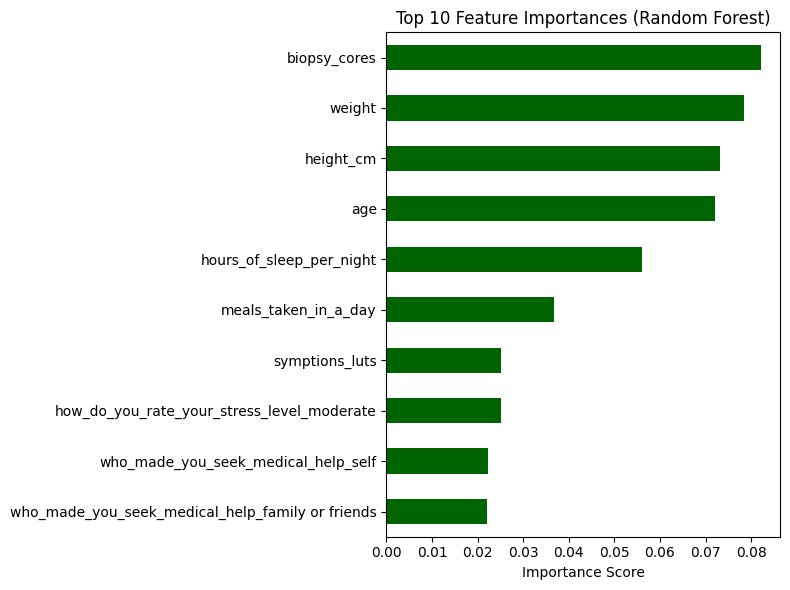

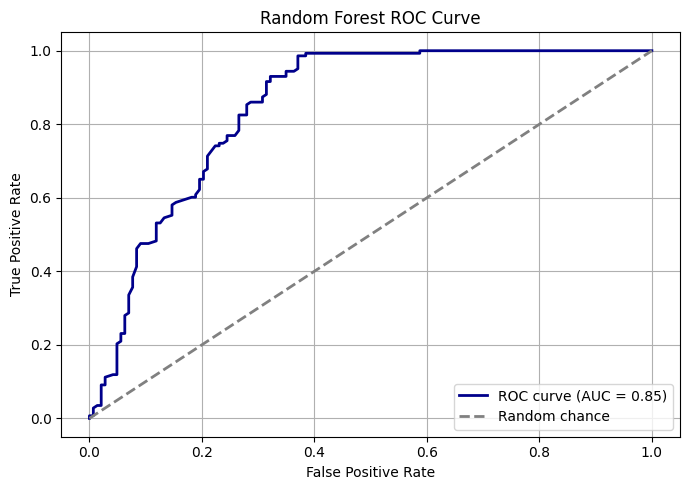

In [2]:
def rf_model_evaluation(X_encoded, y_encoded):
    """
    Full pipeline:
    - SMOTE balancing
    - Train-test split
    - Random Forest hyperparameter tuning (RandomizedSearchCV)
    - Evaluation (classification report, confusion matrix, ROC AUC)
    - Feature importance
    - ROC curve plot

    Parameters:
        X_encoded: pd.DataFrame or np.ndarray, feature matrix
        y_encoded: pd.Series or np.ndarray,  target vector
    """
    from imblearn.over_sampling import SMOTE
    from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
    import matplotlib.pyplot as plt
    import numpy as np

    print("Applying SMOTE...")
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

    print("Splitting data...")
    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
    )

    print("Hyperparameter tuning...")
    param_dist = {
        'n_estimators': [100, 200, 500, 800],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': ['balanced', 'balanced_subsample', None],
        'bootstrap': [True, False]
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestClassifier(random_state=42)

    rf_search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=50, cv=cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, verbose=0
    )
    rf_search.fit(X_train_res, y_train_res)
    best_rf = rf_search.best_estimator_
    print("Best Parameters:", rf_search.best_params_)

    print("Evaluating model...")
    y_pred_rf = best_rf.predict(X_test_res)
    y_prob_rf = best_rf.predict_proba(X_test_res)[:, 1]

    print("\nClassification Report:")
    print(classification_report(y_test_res, y_pred_rf))
    print("Test ROC AUC:", roc_auc_score(y_test_res, y_prob_rf))

    cm = confusion_matrix(y_test_res, y_pred_rf)
    print("\nConfusion Matrix:")
    print(cm)

    # Feature Importances
    importances = best_rf.feature_importances_
    if hasattr(X_encoded, 'columns'):
        feat_names = X_encoded.columns
    else:
        feat_names = [f"Feature {i}" for i in range(X_encoded.shape[1])]
    print("\nTop Feature Importances:")
    for name, val in sorted(zip(feat_names, importances), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{name}: {val:.3f}")
    
    # Feature importance plot (Top 10)
    importances_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)
    plt.figure(figsize=(8,6))
    importances_series.head(10).plot(kind='barh', color='darkgreen')
    plt.gca().invert_yaxis()
    plt.title("Top 10 Feature Importances (Random Forest)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()


    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test_res, y_prob_rf)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Random Forest ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Return useful objects if user wants to use downstream
    return best_rf, rf_search, cm, (fpr, tpr, roc_auc)

# Example usage:
best_rf, rf_search, cm, roc_data = rf_model_evaluation(X_encoded, y_encoded)


# Supporting Vector Classification Model

Balanced train class counts:
categories
0    572
1    572
Name: count, dtype: int64

Test Accuracy: 0.7657

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       143
           1       0.73      0.84      0.78       143

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.76       286
weighted avg       0.77      0.77      0.76       286

ROC AUC: 0.8228

Confusion Matrix (rows: actual, columns: predicted):
[[ 99  44]
 [ 23 120]]

Confusion Matrix Table:
           Predicted 0   Predicted 1
Actual 0            99            44
Actual 1            23           120

Mean Absolute Error (MAE): 0.3432
Mean Squared Error (MSE): 0.1696
Root Mean Squared Error (RMSE): 0.4118
R² Score: 0.3218


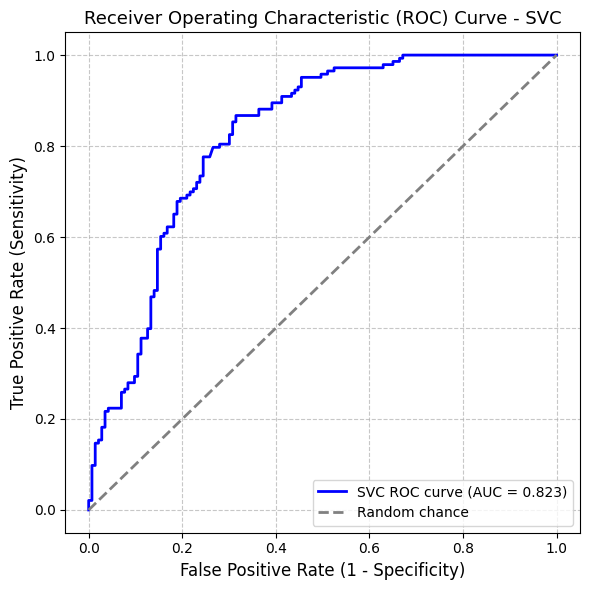


Top 10 Predictions (Actual/Predicted/Probability):
   Actual  Predicted  Probability_Class1
0       0          0            0.095144
1       0          0            0.188582
2       1          1            0.780841
3       0          0            0.400031
4       1          1            0.837742
5       0          0            0.158034
6       0          1            0.463914
7       1          1            0.773933
8       0          0            0.215353
9       0          0            0.384107


In [3]:
def train_evaluate_svc(X_encoded, y_encoded, test_size=0.2, random_state=42):
    """
    Trains and evaluates an SVC model with SMOTE balancing and full metrics reporting,
    including test accuracy, confusion matrix, and top 10 predictions.

    Parameters:
        X_encoded (pd.DataFrame): one-hot encoded feature matrix.
        y_encoded (pd.Series): target vector (binary).
        test_size (float): test split proportion.
        random_state (int): random state for reproducibility.

    Returns:
        svc_model: trained SVC model object.
        metrics: dictionary with classification, accuracy, report, roc_auc, confusion, regression metrics.
    """
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    from imblearn.over_sampling import SMOTE
    from sklearn.svm import SVC
    from sklearn.metrics import (
        classification_report, roc_auc_score, roc_curve, accuracy_score,
        mean_absolute_error, mean_squared_error, r2_score,
        confusion_matrix
    )
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # 1️⃣ SMOTE balancing
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

    # 2️⃣ Train/test split
    X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
        X_res, y_res, test_size=test_size, random_state=random_state, stratify=y_res
    )
    print('Balanced train class counts:')
    print(y_train_sm.value_counts())

    # 3️⃣ Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sm)
    X_test_scaled = scaler.transform(X_test_sm)

    # 4️⃣ Train SVC model
    svc_model = SVC(probability=True, random_state=random_state)
    svc_model.fit(X_train_scaled, y_train_sm)

    # 5️⃣ Predictions
    y_pred = svc_model.predict(X_test_scaled)
    y_prob = svc_model.predict_proba(X_test_scaled)[:, 1]

    # 6️⃣ Metrics
    test_accuracy = accuracy_score(y_test_sm, y_pred)
    clf_report = classification_report(y_test_sm, y_pred)
    roc_auc = roc_auc_score(y_test_sm, y_prob)
    cm = confusion_matrix(y_test_sm, y_pred)
    mae = mean_absolute_error(y_test_sm, y_prob)
    mse = mean_squared_error(y_test_sm, y_prob)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_sm, y_prob)

    print(f"\nTest Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report:\n", clf_report)
    print(f"ROC AUC: {roc_auc:.4f}")

    print("\nConfusion Matrix (rows: actual, columns: predicted):")
    print(cm)
    print(f"\nConfusion Matrix Table:")
    print("           Predicted 0   Predicted 1")
    print(f"Actual 0    {cm[0,0]:>10}   {cm[0,1]:>11}")
    print(f"Actual 1    {cm[1,0]:>10}   {cm[1,1]:>11}")

    print(f"\nMean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # 7️⃣ ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test_sm, y_prob)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'SVC ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random chance')
    plt.title('Receiver Operating Characteristic (ROC) Curve - SVC', fontsize=13)
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 8️⃣ Display top 10 predicted values in a table
    preds_df = pd.DataFrame({
        'Actual': y_test_sm.values,
        'Predicted': y_pred,
        'Probability_Class1': y_prob
    }).reset_index(drop=True)
    print("\nTop 10 Predictions (Actual/Predicted/Probability):")
    print(preds_df.head(10).to_string(index=True))

    # 9️⃣ Return model and results
    metrics = {
        'test_accuracy': test_accuracy,
        'classification_report': clf_report,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2,
        'top_10_predictions': preds_df.head(10)
    }
    return svc_model, metrics

# USAGE EXAMPLE:
svc_model, svc_metrics = train_evaluate_svc(X_encoded, y_encoded)


### 📊 Gradient Boosting Regressor Evaluation Metrics


Balanced training target class counts:
categories
0    572
1    572
Name: count, dtype: int64

Test Accuracy: 0.7168

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.71       143
           1       0.70      0.76      0.73       143

    accuracy                           0.72       286
   macro avg       0.72      0.72      0.72       286
weighted avg       0.72      0.72      0.72       286

ROC AUC: 0.7957

Confusion Matrix (rows: actual, columns: predicted):
[[ 97  46]
 [ 35 108]]

Confusion Matrix Table:
           Predicted 0   Predicted 1
Actual 0            97            46
Actual 1            35           108

Mean Absolute Error (MAE): 0.3795
Mean Squared Error (MSE): 0.1793
Root Mean Squared Error (RMSE): 0.4234
R² Score: 0.2828


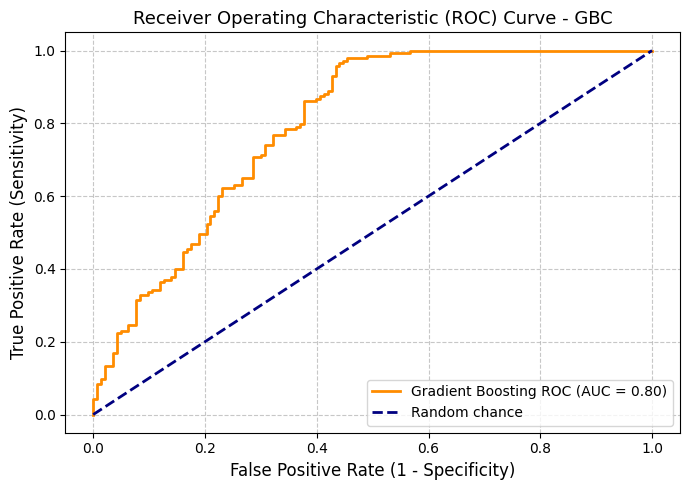


Top 10 Predictions (Actual/Predicted/Probability):
   Actual  Predicted  Probability_Class1
0       0          0            0.073015
1       0          0            0.048715
2       1          1            0.628721
3       0          0            0.267708
4       1          1            0.577053
5       0          0            0.074784
6       0          0            0.436450
7       1          1            0.623066
8       0          0            0.098611
9       0          1            0.817343


In [4]:
def train_evaluate_gbc(X, y, test_size=0.2, random_state=42):
    """
    Train a Gradient Boosting Classifier with SMOTE balancing, 
    evaluate its performance, and plot the ROC curve.

    Parameters:
        X (DataFrame or array): Features
        y (Series or array): Target labels
        test_size (float): Proportion for test split
        random_state (int): Random seed

    Returns:
        model: Trained Gradient Boosting model
        metrics (dict): Dictionary of key evaluation metrics
    """
    from imblearn.over_sampling import SMOTE
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.metrics import (
        classification_report, roc_auc_score, roc_curve, accuracy_score,
        mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
    )
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # ===== 1️⃣ SMOTE Oversampling =====
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X, y)

    # ===== 2️⃣ Split Data =====
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=test_size, random_state=random_state, stratify=y_res
    )
    print("\nBalanced training target class counts:")
    print(y_train.value_counts())

    # ===== 3️⃣ Train Gradient Boosting Model =====
    gbc_model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, random_state=random_state
    )
    gbc_model.fit(X_train, y_train)

    # ===== 4️⃣ Predictions =====
    y_pred = gbc_model.predict(X_test)
    y_prob = gbc_model.predict_proba(X_test)[:, 1]

    # ===== 5️⃣ Classification Metrics =====
    test_accuracy = accuracy_score(y_test, y_pred)
    clf_report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nTest Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report:\n", clf_report)
    print(f"ROC AUC: {roc_auc:.4f}")

    print("\nConfusion Matrix (rows: actual, columns: predicted):")
    print(cm)
    print(f"\nConfusion Matrix Table:")
    print("           Predicted 0   Predicted 1")
    print(f"Actual 0    {cm[0,0]:>10}   {cm[0,1]:>11}")
    print(f"Actual 1    {cm[1,0]:>10}   {cm[1,1]:>11}")

    # ===== 6️⃣ Regression-style Metrics =====
    mae = mean_absolute_error(y_test, y_prob)
    mse = mean_squared_error(y_test, y_prob)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_prob)
    print(f"\nMean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # ===== 7️⃣ ROC Curve =====
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Gradient Boosting ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2,
             linestyle='--', label='Random chance')
    plt.title('Receiver Operating Characteristic (ROC) Curve - GBC', fontsize=13)
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ===== 8️⃣ Top 10 Predicted Values Table =====
    preds_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred,
        'Probability_Class1': y_prob
    }).reset_index(drop=True)
    print("\nTop 10 Predictions (Actual/Predicted/Probability):")
    print(preds_df.head(10).to_string(index=True))

    # ===== 9️⃣ Return Model and Metrics =====
    metrics = {
        "test_accuracy": test_accuracy,
        "classification_report": clf_report,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "top_10_predictions": preds_df.head(10)
    }

    return gbc_model, metrics

# USAGE EXAMPLE:
gbc_model, gbc_metrics = train_evaluate_gbc(X_encoded, y_encoded)


### Ensemble Model

Test Accuracy: 0.7972
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79       143
           1       0.77      0.84      0.81       143

    accuracy                           0.80       286
   macro avg       0.80      0.80      0.80       286
weighted avg       0.80      0.80      0.80       286

ROC AUC: 0.8537
Mean CV ROC AUC: 0.8236
Confusion Matrix:
 [[108  35]
 [ 23 120]]
Confusion Matrix Table:
           Predicted 0   Predicted 1
Actual 0           108            35
Actual 1            23           120

Top 10 Predictions (Actual/Predicted/Probability):
   Actual  Predicted  Probability_Class1
0       0          0            0.101035
1       0          0            0.159603
2       1          1            0.659657
3       0          0            0.215889
4       1          1            0.593570
5       0          0            0.146321
6       0          0            0.402563
7       1          1          

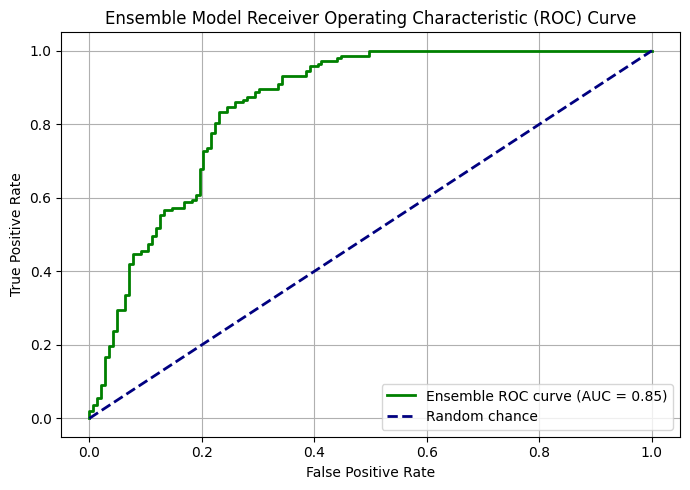

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    accuracy_score, roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def train_evaluate_voting_ensemble(X_encoded, y_encoded, best_rf, cv=5, random_state=42):
    """
    Full pipeline: SMOTE, split, scale, train VotingClassifier (SVC, RandomForest, GBC),
    cross-validated ROC AUC, metrics, confusion matrix, top 10 predictions, and ROC plot.
    """
    # 1️⃣ SMOTE balancing
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

    # 2️⃣ Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res,
        test_size=0.2, random_state=random_state, stratify=y_res
    )

    # 3️⃣ Feature scaling (for all, for pipeline simplicity)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4️⃣ Ensemble base models
    svc_model = SVC(probability=True, random_state=random_state)
    gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=random_state)

    ensemble = VotingClassifier(
        estimators=[('svc', svc_model), ('rf', best_rf), ('gbc', gbc_model)],
        voting='soft',
        weights=[1, 2, 2]  # optional: more weight to RF & GBC
    )

    # 5️⃣ Cross-validation ROC AUC
    cv_scores = cross_val_score(ensemble, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    mean_cv_roc_auc = cv_scores.mean()

    # 6️⃣ Fit to training data
    ensemble.fit(X_train_scaled, y_train)

    # 7️⃣ Evaluate on test data
    y_pred = ensemble.predict(X_test_scaled)
    y_prob = ensemble.predict_proba(X_test_scaled)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)
    clf_report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test Accuracy: {test_accuracy:.4f}")
    print("Classification Report:\n", clf_report)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Mean CV ROC AUC: {mean_cv_roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Confusion Matrix Table:")
    print("           Predicted 0   Predicted 1")
    print(f"Actual 0    {cm[0,0]:>10}   {cm[0,1]:>11}")
    print(f"Actual 1    {cm[1,0]:>10}   {cm[1,1]:>11}")

    # Top 10 test predictions
    preds_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred,
        'Probability_Class1': y_prob
    }).reset_index(drop=True)
    print("\nTop 10 Predictions (Actual/Predicted/Probability):")
    print(preds_df.head(10).to_string(index=True))

    # ROC Curve Plot
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='green', lw=2, label=f'Ensemble ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Ensemble Model Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    metrics = {
        "test_accuracy": test_accuracy,
        "classification_report": clf_report,
        "roc_auc": roc_auc,
        "mean_cv_roc_auc": mean_cv_roc_auc,
        "confusion_matrix": cm,
        "top_10_predictions": preds_df.head(10)
    }
    return ensemble, metrics

# Example for defining best_rf (if you haven't tuned it, this will work as a starting point):
# best_rf = RandomForestClassifier(n_estimators=500, random_state=42)

# USAGE (replace X_encoded and y_encoded with your data variables):
ensemble, ensemble_metrics = train_evaluate_voting_ensemble(X_encoded, y_encoded, best_rf)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best ROC AUC from CV: 0.8258
Best Hyperparameters: {'gbc__learning_rate': 0.05, 'gbc__n_estimators': 100, 'rf__max_depth': None, 'rf__n_estimators': 200, 'svc__C': 1, 'svc__kernel': 'rbf', 'weights': (1, 1, 1)}
Test Accuracy: 0.8042
Test ROC AUC: 0.8620

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.76      0.79       143
           1       0.78      0.85      0.81       143

    accuracy                           0.80       286
   macro avg       0.81      0.80      0.80       286
weighted avg       0.81      0.80      0.80       286


Confusion Matrix:
 [[108  35]
 [ 21 122]]

Top 10 Predictions (Actual/Predicted/Probability):
   Actual  Predicted  Probability_Class1
0       0          0            0.105929
1       0          0            0.185952
2       1          1            0.658824
3       0          0            0.267507
4       1          1          

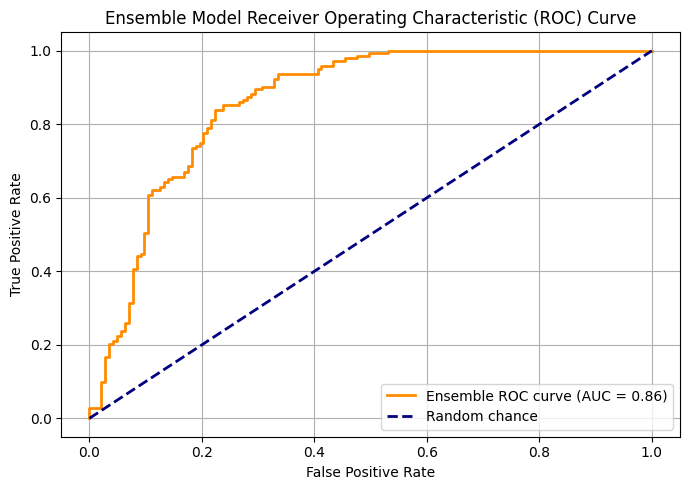

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, accuracy_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# STEP 1: SMOTE Oversampling (replace X_encoded, y_encoded with your variable names)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

# STEP 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# STEP 3: Feature Scaling (needed for VotingClassifier if SVC is included)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 4: Define Base Models
svc = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(random_state=42)
gbc = GradientBoostingClassifier(random_state=42)

# STEP 5: Voting Classifier
ensemble = VotingClassifier(estimators=[
    ('svc', svc),
    ('rf', rf),
    ('gbc', gbc)
], voting='soft')

# STEP 6: Parameter Grid
param_grid = {
    # SVC params
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['rbf', 'linear'],
    # Random Forest params
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 5, 10],
    # Gradient Boosting params
    'gbc__n_estimators': [100, 150],
    'gbc__learning_rate': [0.05, 0.1],
    # Ensemble voting weights
    'weights': [(1, 1, 1), (1, 2, 2), (2, 1, 2)]
}

# STEP 7: GridSearchCV for Hyperparameter Tuning
grid = GridSearchCV(
    estimator=ensemble,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

# STEP 8: Fit GridSearchCV
grid.fit(X_train_scaled, y_train)

# STEP 9: Evaluation on Test Set
y_pred = grid.best_estimator_.predict(X_test_scaled)
y_prob = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
test_accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
clf_report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Best ROC AUC from CV: {grid.best_score_:.4f}")
print("Best Hyperparameters:", grid.best_params_)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", clf_report)
print("\nConfusion Matrix:\n", cm)
print("\nTop 10 Predictions (Actual/Predicted/Probability):")
preds_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability_Class1': y_prob
}).reset_index(drop=True)
print(preds_df.head(10).to_string(index=True))

# STEP 10: ROC Curve Plot
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Ensemble ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Model Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()



Comparison of Model Predictions (first 10 rows):
   Actual  SVC_Pred  RF_Pred  GBC_Pred  Ensemble_Pred
0       0         0        0         0              0
1       0         0        0         0              0
2       1         1        1         1              1
3       0         0        0         0              0
4       1         1        0         1              1
5       0         0        0         0              0
6       0         1        0         0              0
7       1         1        1         1              1
8       0         0        0         0              0
9       0         0        1         1              1

SVC Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       143
           1       0.73      0.84      0.78       143

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.76       286
weighted avg       0.77      0.77      0.76       286

Random Forest R

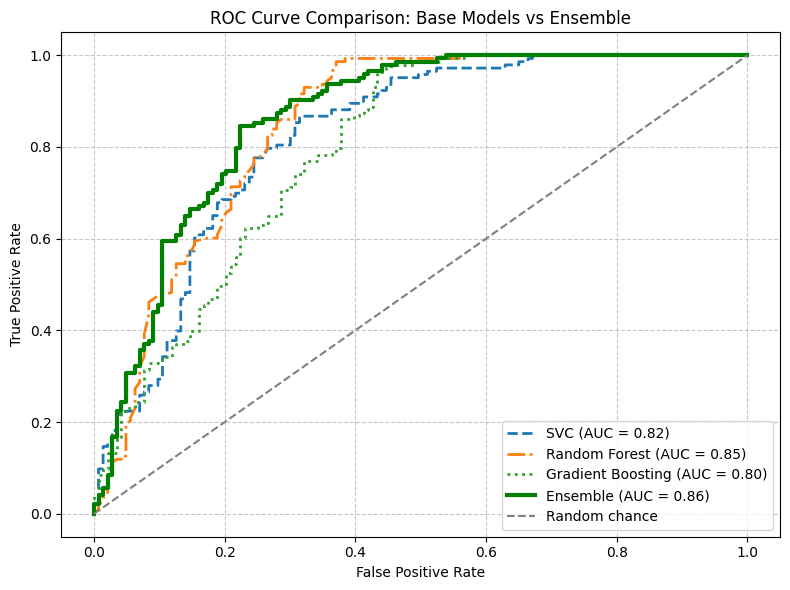


First 5 Actual vs Ensemble Predicted:
    Actual  Predicted
0       0          0
1       0          0
2       1          1
3       0          0
4       1          1


In [13]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def evaluate_voting_ensemble(X_train_scaled, X_test_scaled, y_train, y_test, best_rf=None):
    """
    Train and compare SVC, RandomForest, and GradientBoosting models,
    then combine them into a soft-voting ensemble. Evaluate and visualize performance.

    Parameters:
        X_train_scaled (array): Scaled training features
        X_test_scaled (array): Scaled test features
        y_train (array): Training labels
        y_test (array): Test labels
        best_rf (model, optional): Pre-tuned RandomForest model (from RandomizedSearchCV).
                                   If None, a default RF will be used.

    Returns:
        results (dict): Dictionary containing trained models and metrics
    """

    # --- 1️⃣ Initialize models ---
    svc_model = SVC(probability=True, random_state=42)
    rf_model = best_rf if best_rf is not None else RandomForestClassifier(n_estimators=100, random_state=42)
    gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

    # --- 2️⃣ Fit base models ---
    svc_model.fit(X_train_scaled, y_train)
    rf_model.fit(X_train_scaled, y_train)
    gbc_model.fit(X_train_scaled, y_train)

    # --- 3️⃣ Ensemble model ---
    ensemble = VotingClassifier(
        estimators=[('svc', svc_model), ('rf', rf_model), ('gbc', gbc_model)],
        voting='soft'
    )
    ensemble.fit(X_train_scaled, y_train)

    # --- 4️⃣ Predict labels and probabilities ---
    y_pred_svc = svc_model.predict(X_test_scaled)
    y_pred_rf  = rf_model.predict(X_test_scaled)
    y_pred_gbc = gbc_model.predict(X_test_scaled)
    y_pred_ens = ensemble.predict(X_test_scaled)
    y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]
    y_prob_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]
    y_prob_gbc = gbc_model.predict_proba(X_test_scaled)[:, 1]
    y_prob_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

    # --- 4A️⃣ Create a DataFrame with predictions ---
    prediction_df = pd.DataFrame({
        'Actual': y_test,
        'SVC_Pred': y_pred_svc,
        'RF_Pred': y_pred_rf,
        'GBC_Pred': y_pred_gbc,
        'Ensemble_Pred': y_pred_ens
    }).reset_index(drop=True)
    print("\nComparison of Model Predictions (first 10 rows):")
    print(prediction_df.head(10).to_string(index=True))

    # --- 5️⃣ Classification Reports ---
    print("\nSVC Report:\n", classification_report(y_test, y_pred_svc))
    print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
    print("Gradient Boost Report:\n", classification_report(y_test, y_pred_gbc))
    print("Ensemble Report:\n", classification_report(y_test, y_pred_ens))

    # --- 6️⃣ ROC AUC Scores ---
    auc_svc = roc_auc_score(y_test, y_prob_svc)
    auc_rf = roc_auc_score(y_test, y_prob_rf)
    auc_gbc = roc_auc_score(y_test, y_prob_gbc)
    auc_ens = roc_auc_score(y_test, y_prob_ens)
    print(f"SVC ROC AUC: {auc_svc:.4f}")
    print(f"RF ROC AUC: {auc_rf:.4f}")
    print(f"GBC ROC AUC: {auc_gbc:.4f}")
    print(f"Ensemble ROC AUC: {auc_ens:.4f}")

    # --- 7️⃣ Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred_ens)
    print("\nEnsemble Confusion Matrix:\n", cm)

    # --- 8️⃣ ROC Curve Plot ---
    fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
    fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_prob_gbc)
    fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ens)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_svc, tpr_svc, lw=2, label=f'SVC (AUC = {auc_svc:.2f})', linestyle='--')
    plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})', linestyle='-.')
    plt.plot(fpr_gbc, tpr_gbc, lw=2, label=f'Gradient Boosting (AUC = {auc_gbc:.2f})', linestyle=':')
    plt.plot(fpr_ens, tpr_ens, lw=3, color='green', label=f'Ensemble (AUC = {auc_ens:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison: Base Models vs Ensemble')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- 9️⃣ Actual vs Predicted (Preview) ---
    comparison_df = pd.DataFrame({
        'Actual': np.array(y_test)[:5],
        'Predicted': y_pred_ens[:5]
    })
    print("\nFirst 5 Actual vs Ensemble Predicted:\n", comparison_df)

    # --- 🔟 Return results ---
    results = {
        "svc_model": svc_model,
        "rf_model": rf_model,
        "gbc_model": gbc_model,
        "ensemble": ensemble,
        "auc_scores": {
            "svc": auc_svc,
            "rf": auc_rf,
            "gbc": auc_gbc,
            "ensemble": auc_ens
        },
        "confusion_matrix": cm,
        "prediction_table": prediction_df
    }

    return results

# Example usage (replace variables with your data):
results = evaluate_voting_ensemble(X_train_scaled, X_test_scaled, y_train, y_test, best_rf=rf_search.best_estimator_)
